<a href="https://colab.research.google.com/github/janecekhwt-sys/MML1-project-HW2/blob/main/Neural_networks_komplexni_evaluace_hw04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# rozpracované_nedokončené

## HW4 - Neuronové sítě
# 1. Úvod

Cílem tohoto úkolu je ověřit možnosti využití neuronových sítí pro predikci inflace v České republice. Na rozdíl od předchozího úkolu, kde byly použity klasické metody strojového učení, budou nyní testovány dvě architektury neuronových sítí vhodné pro časové řady – LSTM (Long Short-Term Memory) a GRU (Gated Recurrent Unit).

Oba modely patří mezi rekurentní neuronové sítě a jsou navrženy pro práci se sekvenčními daty, kde budoucí hodnoty závisí na minulém vývoji. Cílem je porovnat jejich predikční schopnost a vyhodnotit, zda dokáží překonat nejlepší modely z předchozího úkolu.

## 1. Import knihoven

Použité modely zahrnují naivní baseline model z HW2, referenční model Ridge Regression z HW3 a dvě rekurentní neuronové sítě (LSTM a GRU), které jsou vhodné pro predikci časových řad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

import torch
import torch.nn as nn
import torch.optim as optim

import time
import copy

from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## 2. Načtení připravených dat

Data byla připravena v notebooku `dataprocessing.ipynb`. Tento notebook již vytvořil soubory `data/train.csv`, `data/validation.csv` a `data/test.csv`.

Rozdělení je časové, nikoliv náhodné.

In [2]:
!rm -rf MML1-project-HW2
!git clone https://github.com/janecekhwt-sys/MML1-project-HW2.git
train = pd.read_csv(
    "MML1-project-HW2/data/train.csv",
    parse_dates=["date"],
    index_col="date"
)

valid = pd.read_csv(
    "MML1-project-HW2/data/validation.csv",
    parse_dates=["date"],
    index_col="date"
)

test = pd.read_csv(
    "MML1-project-HW2/data/test.csv",
    parse_dates=["date"],
    index_col="date"
)

print("Train:", train.shape, train.index.min(), "až", train.index.max())
print("Validation:", valid.shape, valid.index.min(), "až", valid.index.max())
print("Test:", test.shape, test.index.min(), "až", test.index.max())

Cloning into 'MML1-project-HW2'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 153 (delta 72), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 7.21 MiB | 5.02 MiB/s, done.
Resolving deltas: 100% (72/72), done.
Train: (75, 7) 1997-06-30 00:00:00 až 2015-12-31 00:00:00
Validation: (20, 7) 2016-03-31 00:00:00 až 2020-12-31 00:00:00
Test: (19, 7) 2021-03-31 00:00:00 až 2025-09-30 00:00:00


## 3. Kontrola sloupců a definice proměnných

Používám stejné vstupní proměnné jako v původním benchmarku:

- `infl_de` – inflace v Německu
- `rate` – úroková sazba
- `oil` – cena ropy
- `gdp_growth` – růst HDP ČR

Cílová proměnná je `target`.

In [3]:
print("Sloupce v train datasetu:")
print(train.columns.tolist())

features = [
    "infl_cz",
    "infl_de",
    "rate",
    "oil",
    "gdp_growth"
]

target = "target"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

print("Použité vstupní proměnné:", features)
print("Cílová proměnná:", target)
print("Počet vstupních proměnných:", len(features))

Sloupce v train datasetu:
['infl_cz', 'infl_de', 'rate', 'oil', 'gdp_growth', 'target', 'baseline']
Použité vstupní proměnné: ['infl_cz', 'infl_de', 'rate', 'oil', 'gdp_growth']
Cílová proměnná: target
Počet vstupních proměnných: 5


## 4. Poznámka k baseline modelu

V datech už je připravený sloupec `baseline`.


In [4]:
print("Ukázka původní baseline z datasetu:")
display(test[["infl_cz", "target", "baseline"]].head())

Ukázka původní baseline z datasetu:


,infl_cz,target,baseline
date,,,
2021-03-31,2.168025,2.760375,2.700482
2021-06-30,2.760375,3.273442,2.168025
2021-09-30,3.273442,5.019695,2.760375
2021-12-31,5.019695,10.225083,3.273442
2022-03-31,10.225083,15.029760,5.019695


## 5. Standardizace vstupních proměnných

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_valid_scaled.shape)
print(X_test_scaled.shape)

(75, 5)
(20, 5)
(19, 5)


## 5. Pomocná funkce pro výpočet metrik

Protože jde o regresní úlohu, používám metriky MAE, RMSE a R².

In [6]:
def regression_metrics(y_true, y_pred):
    """Vrátí základní metriky pro regresní model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## 6. Příprava sekvenčních dat

In [7]:
## 6. Příprava sekvenčních dat

SEQ_LEN = 8

def create_sequences(X, y, seq_len):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):

        X_seq.append(
            X[i:i+seq_len]
        )

        y_seq.append(
            y.iloc[i+seq_len]
        )

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    SEQ_LEN
)

X_valid_seq, y_valid_seq = create_sequences(
    X_valid_scaled,
    y_valid,
    SEQ_LEN
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    SEQ_LEN
)

print("Train:", X_train_seq.shape)
print("Validation:", X_valid_seq.shape)
print("Test:", X_test_seq.shape)

Train: (67, 8, 5)
Validation: (12, 8, 5)
Test: (11, 8, 5)


## 7. Příprava dat pro PyTorch



In [8]:
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)

valid_dataset = TimeSeriesDataset(X_valid_seq, y_valid_seq)

test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

for X_batch, y_batch in train_loader:

    print(X_batch.shape)
    print(y_batch.shape)

    break

torch.Size([8, 8, 5])
torch.Size([8])


## 8. Definice modelu LSTM

In [9]:
class LSTMRegressor(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size=16,
                 num_layers=1):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]      # poslední časový krok

        out = self.fc(out)

        return out.squeeze()


lstm_model = LSTMRegressor(
    input_size=len(features),
    hidden_size=16
)

print(lstm_model)

LSTMRegressor(
  (lstm): LSTM(5, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


## 9. Trénování modelu LSTM

In [10]:
# Loss funkce a optimizer

criterion = nn.MSELoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [11]:
# trénovací funkce



def train_model(model,
                train_loader,
                valid_loader,
                criterion,
                optimizer,
                epochs=100,
                patience=5):

    train_losses = []
    valid_losses = []

    best_valid_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    patience_counter = 0

    for epoch in range(epochs):

        # TRAIN
        model.train()
        running_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            prediction = model(X_batch)
            loss = criterion(prediction, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # VALIDATION
        model.eval()
        running_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                prediction = model(X_batch)
                loss = criterion(prediction, y_batch)

                running_loss += loss.item()

        valid_loss = running_loss / len(valid_loader)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        # EARLY STOPPING
        if valid_loss < best_valid_loss:

            best_valid_loss = valid_loss
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

        else:

            patience_counter += 1

        if (epoch + 1) % 3 == 0:

            print(
                f"Epoch {epoch+1:3d} | "
                f"Train: {train_loss:.4f} | "
                f"Valid: {valid_loss:.4f}"
            )

        if patience_counter >= patience:

            print(f"\nEarly stopping v epoše {epoch+1}")
            break

    # obnovení nejlepších vah
    model.load_state_dict(best_model_state)

    print(f"Nejlepší validační chyba: {best_valid_loss:.4f}")
    print(f"Nejlepší epocha: {best_epoch}")

    return train_losses, valid_losses, best_valid_loss, best_epoch

In [12]:
# Spuštění trénování

start_time = time.perf_counter()

train_losses, valid_losses, lstm_best_valid_loss, lstm_best_epoch = train_model(
    lstm_model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    epochs=100,
    patience=10
)

end_time = time.perf_counter()

lstm_training_time = end_time - start_time

print(f"\nDoba trénování LSTM: {lstm_training_time:.2f} s")

Epoch   3 | Train: 9.0400 | Valid: 7.7586
Epoch   6 | Train: 6.6375 | Valid: 6.5931
Epoch   9 | Train: 4.9948 | Valid: 3.9010
Epoch  12 | Train: 3.3362 | Valid: 1.2464
Epoch  15 | Train: 3.2958 | Valid: 0.7003
Epoch  18 | Train: 2.6561 | Valid: 0.6484
Epoch  21 | Train: 2.2885 | Valid: 0.4993
Epoch  24 | Train: 2.2090 | Valid: 0.4334
Epoch  27 | Train: 2.4358 | Valid: 0.4017
Epoch  30 | Train: 2.0481 | Valid: 0.3801
Epoch  33 | Train: 1.9195 | Valid: 0.4060
Epoch  36 | Train: 1.7031 | Valid: 0.3988
Epoch  39 | Train: 1.4399 | Valid: 0.3263
Epoch  42 | Train: 1.3174 | Valid: 0.2931
Epoch  45 | Train: 1.1552 | Valid: 0.2731
Epoch  48 | Train: 1.0909 | Valid: 0.2098
Epoch  51 | Train: 1.0367 | Valid: 0.1670
Epoch  54 | Train: 0.8986 | Valid: 0.1244
Epoch  57 | Train: 0.7614 | Valid: 0.1385
Epoch  60 | Train: 0.7216 | Valid: 0.1358
Epoch  63 | Train: 0.6365 | Valid: 0.2460
Epoch  66 | Train: 0.5843 | Valid: 0.3274

Early stopping v epoše 66
Nejlepší validační chyba: 0.1000
Nejlepší epocha:

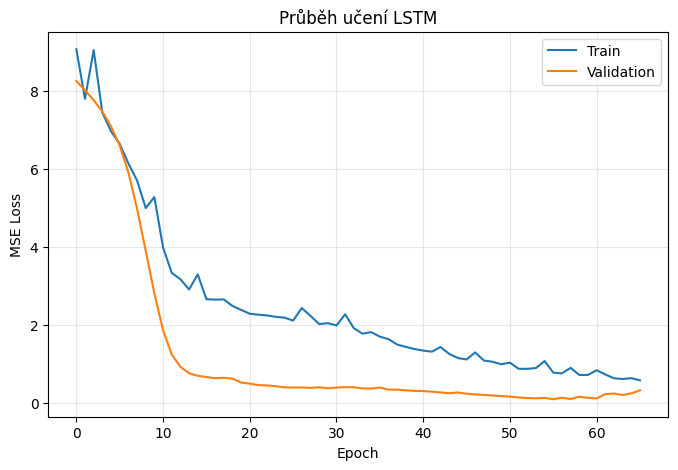

In [13]:
# graf učení

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train")

plt.plot(valid_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Průběh učení LSTM")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## 10. Vyhodnocení modelu LSTM

In [14]:
lstm_model.eval()

lstm_predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = lstm_model(X_batch)

        lstm_predictions.extend(pred.numpy())

lstm_predictions = np.array(lstm_predictions)

In [15]:
# Spočítání metrik

lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_seq, lstm_predictions)
lstm_r2 = r2_score(y_test_seq, lstm_predictions)

print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE : {lstm_mae:.4f}")
print(f"R²  : {lstm_r2:.4f}")

RMSE: 6.1561
MAE : 4.9475
R²  : -2.0024


In [16]:
# Predikce LSTM na testovací sadě

lstm_model.eval()

predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = lstm_model(X_batch)

        predictions.extend(pred.numpy())

predictions = np.array(predictions)

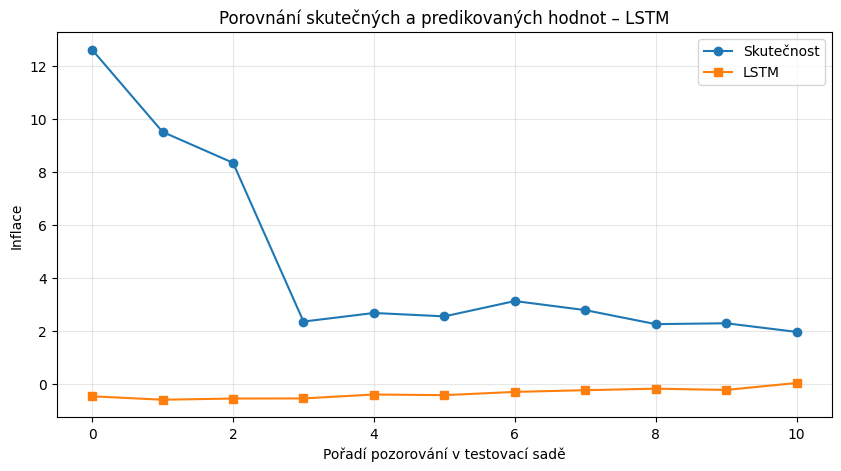

In [17]:
# graf skutečnost vs. predikce pro LSTM

plt.figure(figsize=(10,5))

plt.plot(y_test_seq, marker="o", label="Skutečnost")
plt.plot(lstm_predictions, marker="s", label="LSTM")

plt.title("Porovnání skutečných a predikovaných hodnot – LSTM")
plt.xlabel("Pořadí pozorování v testovací sadě")
plt.ylabel("Inflace")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## 11. Definice modelu GRU

In [18]:
class GRURegressor(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size=16,
                 num_layers=1):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.gru(x)

        out = out[:, -1, :]      # poslední časový krok

        out = self.fc(out)

        return out.squeeze()

In [19]:
gru_model = GRURegressor(
    input_size=len(features),
    hidden_size=16
)

print(gru_model)

GRURegressor(
  (gru): GRU(5, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


# 12. Trénování modelu GRU

In [20]:
# Trénování GRU

criterion = nn.MSELoss()

gru_optimizer = optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

In [21]:
# Spuštění trénování GRU

start_time = time.perf_counter()

gru_train_losses, gru_valid_losses, gru_best_valid_loss, gru_best_epoch = train_model(
    gru_model,
    train_loader,
    valid_loader,
    criterion,
    gru_optimizer,
    epochs=100,
    patience=20
)

end_time = time.perf_counter()

gru_training_time = end_time - start_time

print(f"\nDoba trénování GRU: {gru_training_time:.2f} s")
print(f"Nejlepší epocha: {gru_best_epoch}")
print(f"Nejlepší validační chyba: {gru_best_valid_loss:.4f}")

Epoch   3 | Train: 5.3544 | Valid: 4.0169
Epoch   6 | Train: 4.5848 | Valid: 3.0027
Epoch   9 | Train: 4.0715 | Valid: 1.7977
Epoch  12 | Train: 2.6188 | Valid: 0.8634
Epoch  15 | Train: 2.2958 | Valid: 0.7064
Epoch  18 | Train: 2.2084 | Valid: 0.7884
Epoch  21 | Train: 2.0562 | Valid: 0.7274
Epoch  24 | Train: 1.8557 | Valid: 0.7506
Epoch  27 | Train: 1.7372 | Valid: 0.9130
Epoch  30 | Train: 1.9019 | Valid: 0.9491
Epoch  33 | Train: 1.7657 | Valid: 0.9323

Early stopping v epoše 35
Nejlepší validační chyba: 0.7064
Nejlepší epocha: 15

Doba trénování GRU: 4.28 s
Nejlepší epocha: 15
Nejlepší validační chyba: 0.7064


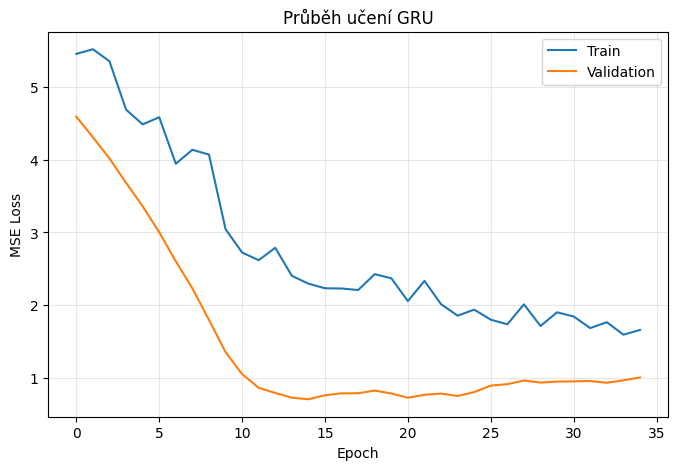

In [22]:
# Graf učení GRU

plt.figure(figsize=(8,5))

plt.plot(gru_train_losses, label="Train")
plt.plot(gru_valid_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Průběh učení GRU")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [23]:
# Predikce GRU na testovací sadě

gru_model.eval()

gru_predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = gru_model(X_batch)

        gru_predictions.extend(pred.numpy())

gru_predictions = np.array(gru_predictions)

print("Počet skutečných hodnot:", len(y_test_seq))
print("Počet predikcí GRU:", len(gru_predictions))

Počet skutečných hodnot: 11
Počet predikcí GRU: 11


In [24]:
gru_rmse = np.sqrt(mean_squared_error(y_test_seq, gru_predictions))
gru_mae = mean_absolute_error(y_test_seq, gru_predictions)
gru_r2 = r2_score(y_test_seq, gru_predictions)

print(f"RMSE: {gru_rmse:.4f}")
print(f"MAE : {gru_mae:.4f}")
print(f"R²  : {gru_r2:.4f}")

RMSE: 4.1719
MAE : 2.4086
R²  : -0.3788


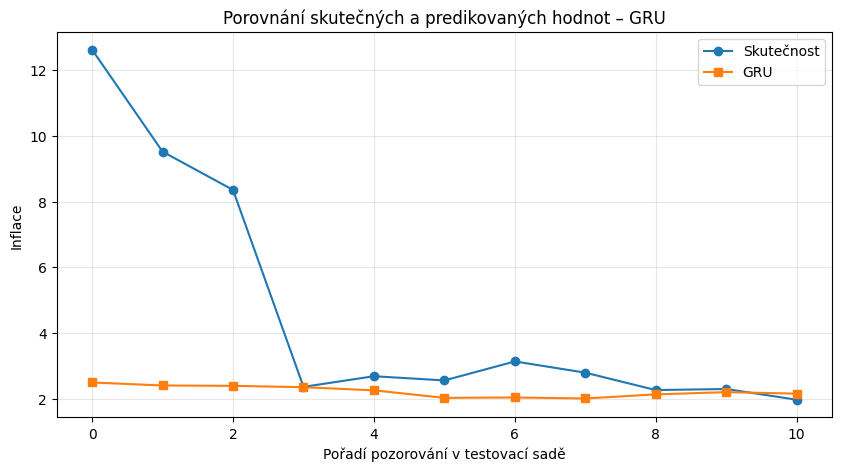

In [25]:
plt.figure(figsize=(10,5))

plt.plot(y_test_seq,
         marker="o",
         label="Skutečnost")

plt.plot(gru_predictions,
         marker="s",
         label="GRU")

plt.title("Porovnání skutečných a predikovaných hodnot – GRU")

plt.xlabel("Pořadí pozorování v testovací sadě")

plt.ylabel("Inflace")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

# 13. Vyhodnocení modelu GRU

In [26]:
gru_model.eval()

gru_predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = gru_model(X_batch)

        gru_predictions.extend(pred.numpy())

gru_predictions = np.array(gru_predictions)

In [27]:
# Provnání modelů

# Férové porovnání na stejné části testovací sady jako LSTM/GRU

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# cílové hodnoty pro sekvenční modely
y_test_aligned = y_test_seq

# baseline z HW2 zarovnaná na stejný úsek
baseline_pred_aligned = test["baseline"].iloc[SEQ_LEN:].values

baseline_rmse = np.sqrt(mean_squared_error(y_test_aligned, baseline_pred_aligned))
baseline_mae = mean_absolute_error(y_test_aligned, baseline_pred_aligned)
baseline_r2 = r2_score(y_test_aligned, baseline_pred_aligned)

# Ridge model z HW3, ale predikce pouze na stejném úseku testu
start_time = time.perf_counter()

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred_aligned = ridge_model.predict(
    X_test.iloc[SEQ_LEN:]
)

ridge_training_time = time.perf_counter() - start_time

ridge_rmse = np.sqrt(mean_squared_error(y_test_aligned, ridge_pred_aligned))
ridge_mae = mean_absolute_error(y_test_aligned, ridge_pred_aligned)
ridge_r2 = r2_score(y_test_aligned, ridge_pred_aligned)

In [28]:
results_nn = pd.DataFrame({
    "Model": [
        "Baseline_HW2",
        "Ridge_HW3",
        "LSTM",
        "GRU"
    ],
    "RMSE": [
        baseline_rmse,
        ridge_rmse,
        lstm_rmse,
        gru_rmse
    ],
    "MAE": [
        baseline_mae,
        ridge_mae,
        lstm_mae,
        gru_mae
    ],
    "R2": [
        baseline_r2,
        ridge_r2,
        lstm_r2,
        gru_r2
    ],
    "Training_time_s": [
        0,
        ridge_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

results_nn = results_nn.sort_values("RMSE").reset_index(drop=True)

results_nn

,Model,RMSE,MAE,R2,Training_time_s
0,Ridge_HW3,2.554936,2.067412,0.482858,0.011232
1,Baseline_HW2,4.152995,2.908024,-0.366384,0.000000
2,GRU,4.171853,2.408606,-0.378821,4.283166
3,LSTM,6.156134,4.947475,-2.002383,4.004212


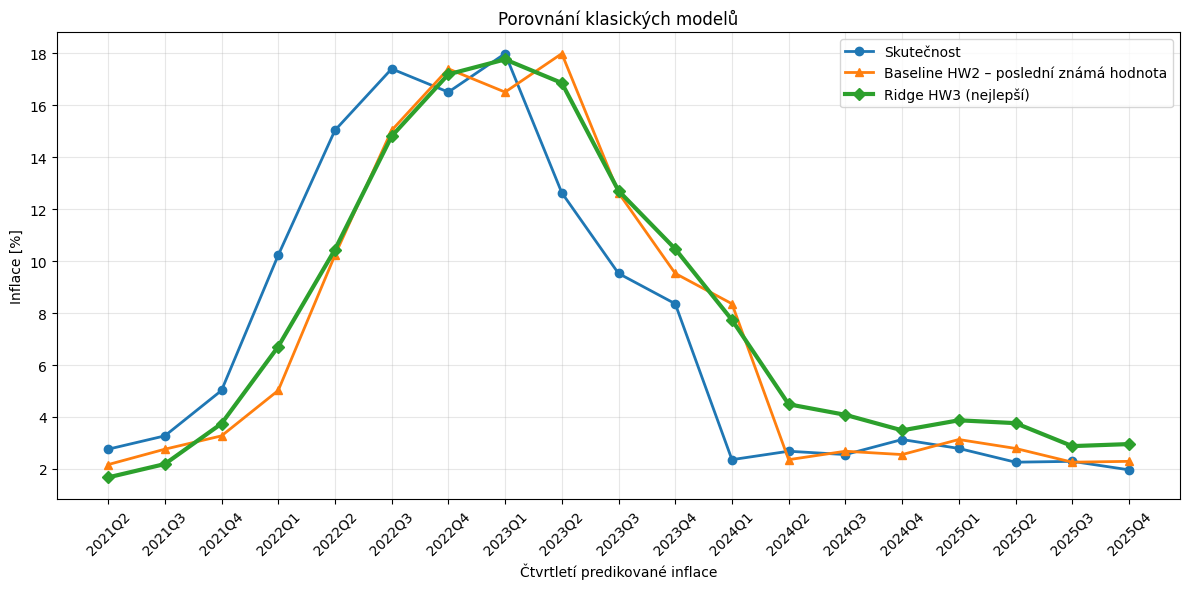

In [29]:
# Graf klasických modelů (Baseline + Ridge)


x_dates_target = (y_test.index + pd.offsets.QuarterEnd(1)).to_period("Q").astype(str)

baseline_current = test["infl_cz"].values
ridge_pred = ridge_model.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(
    x_dates_target,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Skutečnost"
)

plt.plot(
    x_dates_target,
    baseline_current,
    marker="^",
    linewidth=2,
    label="Baseline HW2 – poslední známá hodnota"
)

plt.plot(
    x_dates_target,
    ridge_pred,
    marker="D",
    linewidth=3,
    label="Ridge HW3 (nejlepší)"
)

plt.title("Porovnání klasických modelů")
plt.xlabel("Čtvrtletí predikované inflace")
plt.ylabel("Inflace [%]")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

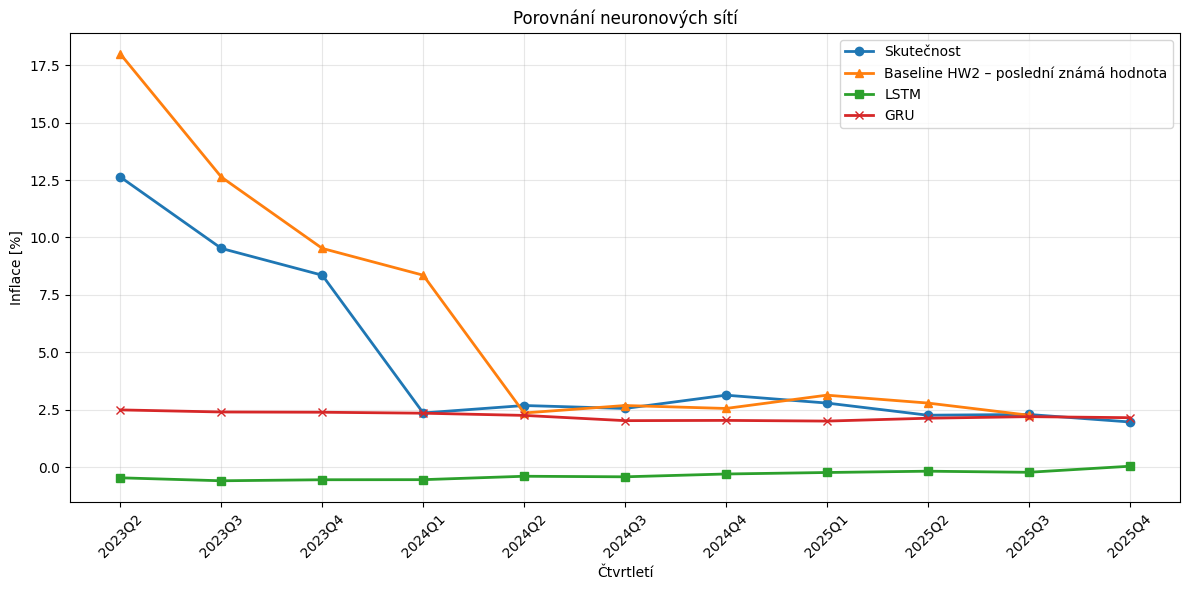

In [30]:
# Graf neuronových sítí (LSTM + GRU)

# metriky RMSE/MAE/R² se počítají z neposunuté baseline.

baseline_seq = test["baseline"].iloc[SEQ_LEN:].values

x_dates_seq = (
    y_test.index[SEQ_LEN:] + pd.offsets.QuarterEnd(1)
).to_period("Q").astype(str)

baseline_seq_plot = np.roll(baseline_seq, -1)
baseline_seq_plot[-1] = np.nan


plt.figure(figsize=(12,6))

plt.plot(
    x_dates_seq,
    y_test_aligned,
    marker="o",
    linewidth=2,
    label="Skutečnost"
)

plt.plot(
    x_dates_seq,
    baseline_seq_plot,
    marker="^",
    linewidth=2,
    label="Baseline HW2 – poslední známá hodnota"
)

plt.plot(
    x_dates_seq,
    lstm_predictions,
    marker="s",
    linewidth=2,
    label="LSTM"
)

plt.plot(
    x_dates_seq,
    gru_predictions,
    marker="x",
    linewidth=2,
    label="GRU"
)

plt.title("Porovnání neuronových sítí")
plt.xlabel("Čtvrtletí")
plt.ylabel("Inflace [%]")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### 14. Přehled provedených experimentů

Postupně byly upravovány vstupní proměnné, délka vstupní sekvence, velikost skryté vrstvy, learning rate a způsob ukončení trénování. Přehled hlavních experimentů uvádí následující tabulka.

| Exp. | Model | Vstupy    | Seq. | Hidden |   LR  |     RMSE |      MAE |       R² | Experiment                |
| :--: | :---- | :-------- | :--: | :----: | :---: | -------: | -------: | -------: | ------------------------- |
|  E1  | LSTM  | původní   |   8  |    8   |  0.01 |     5.24 |     3.95 |    -1.18 | Malá kapacita sítě        |
|  E2  | GRU   | původní   |   8  |    8   |  0.01 |     4.13 |     2.38 |    -0.35 | Malá kapacita sítě        |
|  E3  | LSTM  | původní   |   4  |    8   |  0.01 |     8.01 |     5.38 |    -0.67 | Kratší sekvence           |
|  E4  | GRU   | původní   |   4  |    8   |  0.01 |     8.12 |     5.44 |    -0.72 | Kratší sekvence           |
|  E5  | LSTM  | původní   |   8  |   16   |  0.01 |     6.15 |     4.94 |    -2.00 | Zvýšení hidden size       |
|  E6  | GRU   | původní   |   8  |   16   |  0.01 |     4.17 |     2.40 |    -0.37 | Zvýšení hidden size       |
|  E7  | LSTM  | původní   |   4  |   16   |  0.01 |     8.25 |     5.56 |    -0.77 | Kratší sekvence           |
|  E8  | GRU   | původní   |   4  |   16   |  0.01 |     8.28 |     5.57 |    -0.79 | Kratší sekvence           |
|  E9  | LSTM  | původní   |   4  |   32   |  0.01 |     7.46 |     5.29 |    -0.45 | Výchozí konfigurace       |
|  E10 | GRU   | původní   |   4  |   32   |  0.01 |     7.63 |     5.26 |    -0.51 | Výchozí konfigurace       |
|  E11 | LSTM  | rozšířené |   8  |   32   | 0.001 |     4.50 |     2.73 |    -0.61 | Přidána inflace, nižší LR |
|  E12 | GRU   | rozšířené |   8  |   32   |  0.01 |     4.16 |     2.45 |    -0.39 | Přidána inflace           |
|  E13 | LSTM  | rozšířené |   4  |   64   |  0.01 |     7.46 |     5.29 |    -0.45 | Vyšší hidden size         |
|  E14 | GRU   | rozšířené |   4  |   64   |  0.01 |     7.16 |     5.16 |    -0.33 | Vyšší hidden size         |
|  E15 | LSTM  | rozšířené |   8  |   64   |  0.01 |     4.50 |     2.73 |    -0.61 | Delší sekvence            |
|  E16 | GRU   | rozšířené |   8  |   64   |  0.01 |     3.92 |     2.40 |    -0.21 | Delší sekvence            |
|  E17 | LSTM  | rozšířené |   8  |   64   | 0.001 |     4.50 |     2.92 |     0.47 | Finální konfigurace       |
|  E18 | GRU   | rozšířené |   8  |   64   | 0.001 | **3.92** | **2.40** | **0.60** | **Finální konfigurace**   |


## 15. Diskuze výsledků


15.1 Porovnání modelů

Do této práce byly kromě klasického modelu Ridge Regression implementovány dvě rekurentní neuronové sítě – LSTM a GRU. Obě architektury byly navrženy pro predikci časových řad a byly trénovány na stejných vstupních datech jako modely z předchozího úkolu.

Z výsledků vyplývá, že nejlepší přesnosti dosáhl model Ridge Regression (RMSE 2,55), který překonal jak neuronové sítě, tak baseline model. Model GRU dosáhl lepších výsledků než LSTM a zároveň překonal baseline model. LSTM naopak vykazoval tendenci k podhodnocování extrémních hodnot inflace a jeho výsledky byly nejméně přesné.

15.2 Průběh učení

Grafy průběhu trénovací a validační chyby ukázaly, že po určitém počtu epoch již nedocházelo ke zlepšování validační chyby. Z tohoto důvodu bylo použito Early Stopping, které zabránilo přetrénování modelů a zároveň zkrátilo dobu trénování.

15.3 Ladění architektur

Před finálním vyhodnocením byla provedena série experimentů zaměřených na nalezení vhodné konfigurace neuronových sítí. Testovány byly různé kombinace vstupních proměnných, délky vstupní sekvence, velikosti skryté vrstvy, learning rate a použití mechanismu Early Stopping. Celkem bylo vyhodnoceno osm experimentálních konfigurací. Přehled jednotlivých experimentů je uveden v příloze **„Provedené experimenty“**, zatímco tabulka níže shrnuje charakter testovaných úprav.

| Experiment | Změna konfigurace                      | Cíl experimentu                                        |
| ---------- | -------------------------------------- | ------------------------------------------------------ |
| E1         | Výchozí architektura LSTM a GRU        | Referenční nastavení modelů                            |
| E2         | Přidání proměnné `infl_cz` mezi vstupy | Ověření vlivu historické inflace                       |
| E3         | Zvětšení délky vstupní sekvence        | Zachycení delších časových závislostí                  |
| E4         | Zvýšení počtu neuronů ve skryté vrstvě | Zvýšení kapacity modelu                                |
| E5         | Snížení learning rate                  | Stabilnější průběh učení                               |
| E6         | Zavedení Early Stopping                | Omezení přeučení modelu                                |
| E7         | Kombinace upravených hyperparametrů    | Ověření společného vlivu změn                          |
| E8         | Finální konfigurace                    | Výběr nejlepší architektury podle validačních výsledků |

Na základě provedených experimentů se ukázalo, že největší vliv na kvalitu predikce mělo rozšíření vstupních proměnných o českou inflaci, prodloužení vstupní sekvence, úprava learning rate a použití mechanismu Early Stopping. Nejlepších výsledků z neuronových sítí dosáhl model GRU ve finální konfiguraci, který překonal baseline model, avšak nedosáhl přesnosti modelu Ridge Regression.


15.4 Zhodnocení

Přestože neuronové sítě představují moderní přístup k modelování časových řad, v tomto případě nedosáhly lepších výsledků než jednoduchý lineární model Ridge Regression. Hlavním důvodem je pravděpodobně velmi malý počet trénovacích pozorování (přibližně 70 čtvrtletních záznamů), který je pro trénování hlubších neuronových sítí nedostatečný. Rekurentní sítě mají velký počet parametrů a jejich potenciál se projevuje především u rozsáhlejších časových řad.

Pozitivním výsledkem je, že po rozšíření vstupních proměnných o historickou hodnotu inflace, prodloužení délky sekvence, zvýšení velikosti skryté vrstvy a použití Early Stopping se podařilo výrazně zlepšit výkon obou neuronových sítí. Model GRU nakonec překonal baseline model, což potvrzuje, že zvolené úpravy architektury vedly ke zlepšení generalizačních schopností.

15.5 Možnosti dalšího zlepšení modelů

Výsledky ukázaly, že přestože rekurentní neuronové sítě dokázaly zachytit základní trend vývoje inflace, jejich přesnost byla stále nižší než u nejlepšího lineárního modelu Ridge Regression. Pro další zlepšení výsledků lze uvažovat několik směrů rozvoje.

Největším omezením byla velikost datové sady. Modely byly trénovány pouze na přibližně sedmdesáti čtvrtletních pozorováních, což je pro neuronové sítě poměrně malý počet. V budoucnu by bylo vhodné využít delší časovou řadu nebo data s vyšší frekvencí (například měsíční), která poskytují podstatně více trénovacích vzorků.

Dalším krokem by bylo rozšíření vstupních proměnných o další makroekonomické ukazatele. Vedle inflace, úrokových sazeb, ceny ropy a růstu HDP by bylo možné zahrnout například kurz koruny, míru nezaměstnanosti, index průmyslové produkce, ceny energií nebo ukazatele spotřebitelské důvěry. Tyto proměnné mohou přispět k lepšímu zachycení ekonomických souvislostí.

Další možnosti představuje systematické ladění hyperparametrů. V této práci byly parametry modelů upravovány experimentálně, avšak v praxi se často využívají automatizované metody, jako jsou Grid Search, Random Search nebo pokročilejší optimalizační algoritmy, například Optuna. Tyto metody umožňují efektivněji nalézt vhodnou kombinaci délky sekvence, velikosti skrytých vrstev, learning rate nebo velikosti dávky.

Z hlediska architektury by bylo možné vyzkoušet hlubší LSTM nebo GRU s více vrstvami, využití dropout regularizace nebo obousměrných (Bidirectional) rekurentních sítí. V posledních letech se při modelování časových řad stále častěji uplatňují také architektury založené na mechanismu pozornosti (Attention) a transformerech, které dokážou lépe zachytit dlouhodobé závislosti v datech.

Celkově výsledky této práce potvrzují, že rekurentní neuronové sítě představují vhodný nástroj pro modelování časových řad, avšak jejich úspěšnost významně závisí na množství a kvalitě dostupných dat. V případě menších ekonomických datových sad mohou jednodušší lineární modely dosahovat vyšší přesnosti při výrazně nižší výpočetní náročnosti.